In [2]:
import pandas as pd

nav = pd.read_csv("../data/cleaned_nav_history.csv")
benchmark = pd.read_csv("../data/10_benchmark_indices.csv")
scheme = pd.read_csv("../data/07_scheme_performance.csv")

In [4]:
print(nav.shape)
print(benchmark.shape)
print(scheme.shape)

print(nav.columns.tolist())
print(benchmark.columns.tolist())

(46000, 3)
(8050, 3)
(40, 19)
['amfi_code', 'date', 'nav']
['date', 'index_name', 'close_value']


In [6]:
nav['date'] = pd.to_datetime(nav['date'])
benchmark['date'] = pd.to_datetime(benchmark['date'])

In [8]:
nav = nav.sort_values(['amfi_code', 'date'])

In [10]:
nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
    .pct_change()
)

In [12]:
nav[['amfi_code','date','nav','daily_return']].head(15)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [14]:
nav['daily_return'].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

In [16]:
cagr_data = []

for fund in nav['amfi_code'].unique():
    
    fund_data = nav[nav['amfi_code'] == fund].sort_values('date')
    
    start_nav = fund_data['nav'].iloc[0]
    end_nav = fund_data['nav'].iloc[-1]
    
    years = (
        (fund_data['date'].iloc[-1] -
         fund_data['date'].iloc[0]).days
    ) / 365.25
    
    cagr = ((end_nav / start_nav) ** (1 / years) - 1) * 100
    
    cagr_data.append([fund, cagr])

cagr_df = pd.DataFrame(
    cagr_data,
    columns=['amfi_code', 'cagr_pct']
)

cagr_df.head()

,amfi_code,cagr_pct
0,100016,2.637074
1,100025,4.458210
2,100033,30.123153
3,101206,23.538361
4,101207,7.938765


In [18]:
cagr_df.describe()

,amfi_code,cagr_pct
count,40.000000,40.000000
mean,120247.000000,16.735691
std,14534.998667,10.308961
min,100016.000000,1.171745
25%,118632.750000,6.861841
50%,119551.500000,16.607297
75%,120842.250000,24.488291
max,149324.000000,32.827406


In [20]:
risk_free_rate = 0.065

sharpe_data = []

for fund in nav['amfi_code'].unique():

    fund_returns = nav[
        nav['amfi_code'] == fund
    ]['daily_return'].dropna()

    annual_return = fund_returns.mean() * 252

    annual_volatility = fund_returns.std() * (252 ** 0.5)

    sharpe = (
        annual_return - risk_free_rate
    ) / annual_volatility

    sharpe_data.append([fund, sharpe])

sharpe_df = pd.DataFrame(
    sharpe_data,
    columns=['amfi_code', 'sharpe_ratio']
)

sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [1]:
sharpe_df.describe()

NameError: name 'sharpe_df' is not defined

In [3]:
risk_free_rate = 0.065

sortino_data = []

for fund in nav['amfi_code'].unique():

    fund_returns = nav[
        nav['amfi_code'] == fund
    ]['daily_return'].dropna()

    annual_return = fund_returns.mean() * 252

    downside_returns = fund_returns[fund_returns < 0]

    downside_std = downside_returns.std() * (252 ** 0.5)

    sortino = (
        annual_return - risk_free_rate
    ) / downside_std

    sortino_data.append([fund, sortino])

sortino_df = pd.DataFrame(
    sortino_data,
    columns=['amfi_code', 'sortino_ratio']
)

sortino_df.head()

NameError: name 'nav' is not defined

In [5]:
import pandas as pd
import numpy as np

nav = pd.read_csv("../data/cleaned_nav_history.csv")

nav['date'] = pd.to_datetime(nav['date'])

nav = nav.sort_values(['amfi_code', 'date'])

nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
    .pct_change()
)

In [7]:
nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [9]:
risk_free_rate = 0.065

sortino_data = []

for fund in nav['amfi_code'].unique():

    fund_returns = nav[
        nav['amfi_code'] == fund
    ]['daily_return'].dropna()

    annual_return = fund_returns.mean() * 252

    downside_returns = fund_returns[fund_returns < 0]

    downside_std = downside_returns.std() * (252 ** 0.5)

    sortino = (
        annual_return - risk_free_rate
    ) / downside_std

    sortino_data.append([fund, sortino])

sortino_df = pd.DataFrame(
    sortino_data,
    columns=['amfi_code', 'sortino_ratio']
)

sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [11]:
sortino_df.describe()

,amfi_code,sortino_ratio
count,40.000000,40.000000
mean,120247.000000,0.923338
std,14534.998667,1.005410
min,100016.000000,-1.681038
25%,118632.750000,0.106664
50%,119551.500000,1.116936
75%,120842.250000,1.727739
max,149324.000000,2.385644


In [13]:
drawdown_data = []

for fund in nav['amfi_code'].unique():

    fund_data = nav[
        nav['amfi_code'] == fund
    ].sort_values('date').copy()

    fund_data['running_max'] = (
        fund_data['nav'].cummax()
    )

    fund_data['drawdown'] = (
        fund_data['nav'] /
        fund_data['running_max']
        - 1
    )

    max_dd = fund_data['drawdown'].min()

    drawdown_data.append(
        [fund, max_dd * 100]
    )

drawdown_df = pd.DataFrame(
    drawdown_data,
    columns=[
        'amfi_code',
        'max_drawdown_pct'
    ]
)

drawdown_df.head()

,amfi_code,max_drawdown_pct
0,100016,-24.734441
1,100025,-4.308264
2,100033,-16.217209
3,101206,-11.291596
4,101207,-35.446916


In [15]:
drawdown_df.describe()

,amfi_code,max_drawdown_pct
count,40.000000,40.000000
mean,120247.000000,-17.872901
std,14534.998667,11.268615
min,100016.000000,-52.574221
25%,118632.750000,-21.592719
50%,119551.500000,-16.306976
75%,120842.250000,-11.765276
max,149324.000000,-0.097731


In [17]:
fund_scorecard = (
    cagr_df
    .merge(sharpe_df, on='amfi_code')
    .merge(sortino_df, on='amfi_code')
    .merge(drawdown_df, on='amfi_code')
)

fund_scorecard.head()

NameError: name 'cagr_df' is not defined

In [19]:
%who

annual_return	 downside_returns	 downside_std	 drawdown_data	 drawdown_df	 fund	 fund_data	 fund_returns	 max_dd	 
nav	 np	 pd	 risk_free_rate	 sortino	 sortino_data	 sortino_df	 


In [21]:
cagr_data = []

for fund in nav['amfi_code'].unique():

    fund_data = nav[nav['amfi_code'] == fund].sort_values('date')

    start_nav = fund_data['nav'].iloc[0]
    end_nav = fund_data['nav'].iloc[-1]

    years = (
        (fund_data['date'].iloc[-1] -
         fund_data['date'].iloc[0]).days
    ) / 365.25

    cagr = ((end_nav / start_nav) ** (1 / years) - 1) * 100

    cagr_data.append([fund, cagr])

cagr_df = pd.DataFrame(
    cagr_data,
    columns=['amfi_code', 'cagr_pct']
)

In [23]:
risk_free_rate = 0.065

sharpe_data = []

for fund in nav['amfi_code'].unique():

    fund_returns = nav[
        nav['amfi_code'] == fund
    ]['daily_return'].dropna()

    annual_return = fund_returns.mean() * 252

    annual_volatility = fund_returns.std() * (252 ** 0.5)

    sharpe = (
        annual_return - risk_free_rate
    ) / annual_volatility

    sharpe_data.append([fund, sharpe])

sharpe_df = pd.DataFrame(
    sharpe_data,
    columns=['amfi_code', 'sharpe_ratio']
)

In [25]:
%who

annual_return	 annual_volatility	 cagr	 cagr_data	 cagr_df	 downside_returns	 downside_std	 drawdown_data	 drawdown_df	 
end_nav	 fund	 fund_data	 fund_returns	 max_dd	 nav	 np	 pd	 risk_free_rate	 
sharpe	 sharpe_data	 sharpe_df	 sortino	 sortino_data	 sortino_df	 start_nav	 years	 


In [27]:
fund_scorecard = (
    cagr_df
    .merge(sharpe_df, on='amfi_code')
    .merge(sortino_df, on='amfi_code')
    .merge(drawdown_df, on='amfi_code')
)

fund_scorecard.shape

(40, 5)

In [29]:
fund_scorecard.to_csv(
    "../data/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv created successfully")

fund_scorecard.csv created successfully


In [31]:
import os

'fund_scorecard.csv' in os.listdir('../data')

True

In [33]:
benchmark.head()

NameError: name 'benchmark' is not defined

In [35]:
benchmark = pd.read_csv("../data/10_benchmark_indices.csv")

benchmark['date'] = pd.to_datetime(benchmark['date'])

In [37]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [39]:
benchmark['index_name'].value_counts()

index_name
NIFTY50            1150
NIFTY100           1150
NIFTY_MIDCAP150    1150
BSE_SMALLCAP       1150
NIFTY500           1150
CRISIL_LIQUID      1150
CRISIL_GILT        1150
Name: count, dtype: int64

In [41]:
nifty = benchmark[
    benchmark['index_name'] == 'NIFTY50'
].copy()

nifty = nifty.sort_values('date')

nifty['benchmark_return'] = (
    nifty['close_value']
    .pct_change()
)

nifty.head()

,date,index_name,close_value,benchmark_return
0,2022-01-03,NIFTY50,17492.79,NaN
1,2022-01-04,NIFTY50,17689.64,0.011253
2,2022-01-05,NIFTY50,17835.05,0.008220
3,2022-01-06,NIFTY50,17878.51,0.002437
4,2022-01-07,NIFTY50,17759.15,-0.006676


In [43]:
alpha_beta_data = []

for fund in nav['amfi_code'].unique():

    fund_returns = nav[
        ['date', 'daily_return', 'amfi_code']
    ][nav['amfi_code'] == fund]

    merged = pd.merge(
        fund_returns,
        nifty[['date', 'benchmark_return']],
        on='date',
        how='inner'
    ).dropna()

    beta = (
        merged['daily_return']
        .cov(merged['benchmark_return'])
        /
        merged['benchmark_return']
        .var()
    )

    alpha = (
        merged['daily_return'].mean()
        -
        beta *
        merged['benchmark_return'].mean()
    ) * 252

    alpha_beta_data.append(
        [fund, alpha, beta]
    )

alpha_beta_df = pd.DataFrame(
    alpha_beta_data,
    columns=[
        'amfi_code',
        'alpha',
        'beta'
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.036221,-0.025909
1,100025,0.043189,-0.016176
2,100033,0.272343,-0.011200
3,101206,0.213945,0.033814
4,101207,0.108205,-0.059856


In [45]:
alpha_beta_df.describe()

,amfi_code,alpha,beta
count,40.000000,40.000000,40.000000
mean,120247.000000,0.159003,0.001073
std,14534.998667,0.087390,0.035890
min,100016.000000,0.028949,-0.061476
25%,118632.750000,0.069144,-0.016480
50%,119551.500000,0.162315,-0.001505
75%,120842.250000,0.221010,0.013191
max,149324.000000,0.301114,0.132608


In [47]:
alpha_beta_df.to_csv(
    "../data/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv created successfully")

alpha_beta.csv created successfully


In [49]:
fund_scorecard = (
    fund_scorecard
    .merge(alpha_beta_df, on='amfi_code')
)

fund_scorecard.head()

,amfi_code,cagr_pct,sharpe_ratio,sortino_ratio,max_drawdown_pct,alpha_x,beta_x,alpha_y,beta_y
0,100016,2.637074,-0.201517,-0.351047,-24.734441,0.036221,-0.025909,0.036221,-0.025909
1,100025,4.458210,-0.567095,-0.941821,-4.308264,0.043189,-0.016176,0.043189,-0.016176
2,100033,30.123153,1.093699,1.829134,-16.217209,0.272343,-0.011200,0.272343,-0.011200
3,101206,23.538361,1.027213,1.799563,-11.291596,0.213945,0.033814,0.213945,0.033814
4,101207,7.938765,0.162661,0.276644,-35.446916,0.108205,-0.059856,0.108205,-0.059856


In [51]:
fund_scorecard.shape

(40, 9)

In [53]:
fund_scorecard.to_csv(
    "../data/fund_scorecard.csv",
    index=False
)

In [55]:
fund_scorecard.columns.tolist()

['amfi_code',
 'cagr_pct',
 'sharpe_ratio',
 'sortino_ratio',
 'max_drawdown_pct',
 'alpha_x',
 'beta_x',
 'alpha_y',
 'beta_y']

In [57]:
fund_scorecard.head()

,amfi_code,cagr_pct,sharpe_ratio,sortino_ratio,max_drawdown_pct,alpha_x,beta_x,alpha_y,beta_y
0,100016,2.637074,-0.201517,-0.351047,-24.734441,0.036221,-0.025909,0.036221,-0.025909
1,100025,4.458210,-0.567095,-0.941821,-4.308264,0.043189,-0.016176,0.043189,-0.016176
2,100033,30.123153,1.093699,1.829134,-16.217209,0.272343,-0.011200,0.272343,-0.011200
3,101206,23.538361,1.027213,1.799563,-11.291596,0.213945,0.033814,0.213945,0.033814
4,101207,7.938765,0.162661,0.276644,-35.446916,0.108205,-0.059856,0.108205,-0.059856


In [59]:
fund_scorecard = fund_scorecard.drop(
    columns=['alpha_y', 'beta_y']
)

fund_scorecard = fund_scorecard.rename(
    columns={
        'alpha_x': 'alpha',
        'beta_x': 'beta'
    }
)

fund_scorecard.columns.tolist()

KeyError: "['alpha_y', 'beta_y'] not found in axis"

In [60]:
fund_scorecard.to_csv(
    "../data/fund_scorecard.csv",
    index=False
)

print("Updated scorecard saved")

Updated scorecard saved


In [62]:
fund_scorecard = fund_scorecard.drop(
    columns=['alpha_y', 'beta_y']
)

fund_scorecard = fund_scorecard.rename(
    columns={
        'alpha_x': 'alpha',
        'beta_x': 'beta'
    }
)

fund_scorecard.columns.tolist()

KeyError: "['alpha_y', 'beta_y'] not found in axis"

In [64]:
fund_scorecard.columns

Index(['amfi_code', 'cagr_pct', 'sharpe_ratio', 'sortino_ratio',
       'max_drawdown_pct', 'alpha', 'beta'],
      dtype='object')

In [66]:
fund_scorecard.to_csv(
    "../data/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved")

fund_scorecard.csv saved


In [68]:
top_funds = fund_scorecard.sort_values(
    by='cagr_pct',
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

plt.bar(
    top_funds['amfi_code'].astype(str),
    top_funds['cagr_pct']
)

plt.axhline(
    y=12,
    linestyle='--',
    label='Benchmark CAGR'
)

plt.title("Top Funds vs Benchmark")
plt.xlabel("AMFI Code")
plt.ylabel("CAGR (%)")

plt.legend()

plt.tight_layout()

plt.savefig("../reports/benchmark_comparison.png")

plt.show()

NameError: name 'plt' is not defined

In [70]:
import matplotlib.pyplot as plt

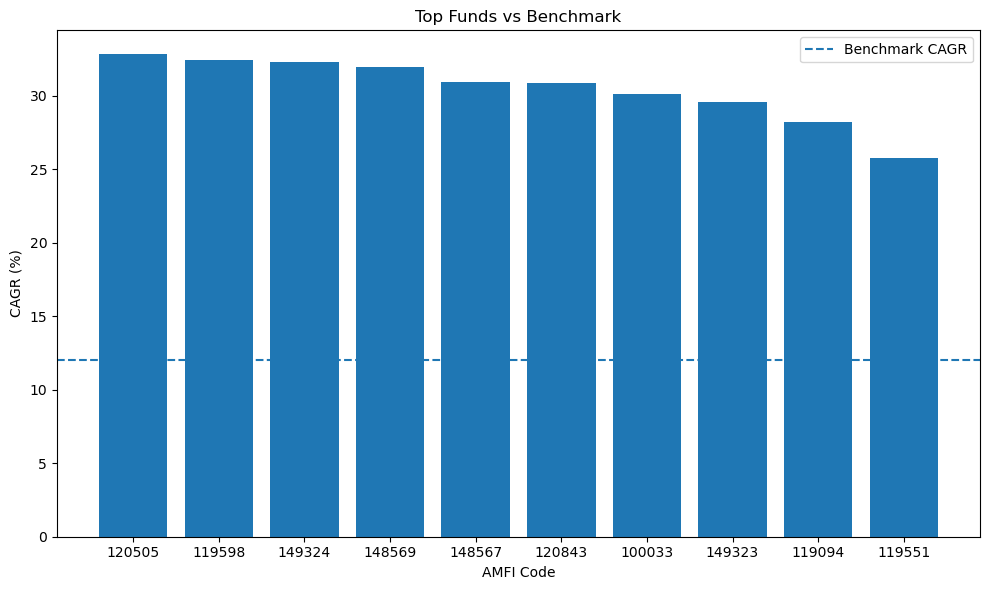

In [72]:
top_funds = fund_scorecard.sort_values(
    by='cagr_pct',
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

plt.bar(
    top_funds['amfi_code'].astype(str),
    top_funds['cagr_pct']
)

plt.axhline(
    y=12,
    linestyle='--',
    label='Benchmark CAGR'
)

plt.title("Top Funds vs Benchmark")
plt.xlabel("AMFI Code")
plt.ylabel("CAGR (%)")

plt.legend()

plt.tight_layout()

plt.savefig("../reports/benchmark_comparison.png")

plt.show()

In [73]:
fund_scorecard.head()
alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.036221,-0.025909
1,100025,0.043189,-0.016176
2,100033,0.272343,-0.011200
3,101206,0.213945,0.033814
4,101207,0.108205,-0.059856
